# Example
## Metric Box Plot as a Function of $x$

An example showing the use of ```inspect.boxplot_metvx```. 

This function is used to visualize how a metric is distributed/varies as a function of a secondary dataset $x$. The metric is calculated using true ($y-true$) and modeled ($y-mod$) values. In some cases depending on the metric scores may be used instead of model values (e.g. ROC AUC).

For each bin in $x$ the passed y-true and y-mod are randomly sampled k-folds times (```kfolds```) using a fraction of the data (```kfrac```). For each sample a metric (default either accuracy or MSE) is derived and the kfolds analysis creates a distribution of the metric for that bin. This distribution is used to calculate values for a box and whisker plot. 

```inspect.boxplot_metx``` can calculate box and whisker values for an arbitrary number of $x$ datasets which are passed as Pandas DataFrame. Lambda function can also be sued to define a specifc metric to use. These can be passed using the ```box_metric``` keyword. In this way users can select a metric but also set keyword parameters for the metric. For example:

```python
met1 = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred)
# or
met2 = lambda y_true, y_pred: metrics.accuracy_score(y_true, y_pred, normalize=False)
```

The example here shows how the Median Absolute Error varies as function of geomagnetic conditions as measured by AE and Sym-H. The model file ```RF_FI_GEO_OOS_CHAMP.hdf5``` contains the predicted and observed density along the CHAMP satellite orbit. The predicted density is from a random forest model of atmospheric neutral density at 400 km altitude. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn.metrics as metrics

path_dat = r"..\data\RF_FI_GEO_OOS_CHAMP.hdf5"

In [4]:
import ml_fw.inspect as inspect

In [5]:
dat = pd.read_hdf(path_dat)
dat.head(1)
dat.describe()

,1300_02,43000_09,85550_13,94400_18,SYM_H index,AE,SatLat,cos_SatMagLT,sin_SatMagLT,cos_SatLon,sin_SatLon,400kmDensity,DateTime,storm,storm phase,400kmDensity_pred
105120,7.648391,10.081208,9.545769,9.306003,-5.0,23.0,43.7912,-0.58071,-0.81411,-0.036139,0.999347,3.659148,2003-01-01,1,2,4.227237


,1300_02,43000_09,85550_13,94400_18,SYM_H index,AE,SatLat,cos_SatMagLT,sin_SatMagLT,cos_SatLon,sin_SatLon,400kmDensity,DateTime,storm,storm phase,400kmDensity_pred
count,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123.000000,790123,790123.000000,790123.000000,790123.000000
mean,7.125412,9.844823,9.427309,9.200223,-11.048346,173.185924,-0.086422,0.000377,-0.000026,-0.000815,-0.000038,1.329478,2006-10-30 09:51:04.483504896,0.118978,0.458584,1.182700
min,6.395051,9.715523,9.369749,9.147454,-488.000000,1.000000,-87.275300,-1.000000,-1.000000,-1.000000,-1.000000,0.000030,2003-01-01 00:00:00,-1.000000,-1.000000,0.072221
25%,6.784116,9.760335,9.389104,9.160233,-17.000000,38.000000,-45.078040,-0.712492,-0.700972,-0.708521,-0.706551,0.544024,2004-11-22 02:37:30,-1.000000,-1.000000,0.482997
50%,7.101278,9.818229,9.412996,9.183772,-8.000000,86.000000,-0.039010,0.000471,-0.000419,-0.001600,-0.000508,0.924439,2006-11-04 19:40:00,1.000000,1.000000,0.814606
75%,7.445087,9.909598,9.456292,9.224175,-1.000000,231.000000,45.039270,0.713630,0.701326,0.706804,0.706477,1.712489,2008-10-01 06:32:30,1.000000,2.000000,1.532888
max,9.525276,26.991252,9.717255,31.744619,92.000000,3529.000000,87.268960,1.000000,1.000000,1.000000,1.000000,25.004950,2010-09-04 00:00:00,1.000000,2.000000,16.233193
std,0.379437,0.210530,0.045686,0.253073,18.807064,211.903991,51.799981,0.710207,0.703993,0.707188,0.707026,1.195350,NaN,0.992898,1.344813,1.047223


In [6]:
# k folds parameters
k_folds = 100
k_size = 0.5

# whisker size
whisker = 1.5

# define the x_cols of dat that we want to use for binning
# and their ranges and number of bins
x_dat = ['AE', 'SYM_H index']
x_bin = [20,21]
x_range = [[0,2000], [-200,10]]
# the y true and predicted values
y_true = ['400kmDensity']
y_pred = ['400kmDensity_pred']

# use accuracy as the metric here
metric = 'Median Absolute Error'
met = lambda y_true, y_pred: metrics.median_absolute_error(y_true, y_pred)
met2 = lambda y_true, y_pred: metrics.mean_absolute_error(y_true, y_pred)

In [10]:
met_box = inspect.boxplot_metvx(x_dat, y_true, y_pred, box_dat=dat, bins=x_bin, 
                                    xrange=x_range, kfolds=k_folds, kfrac=k_size, 
                                    box_metric={'mdae':met,'mnae':met2})

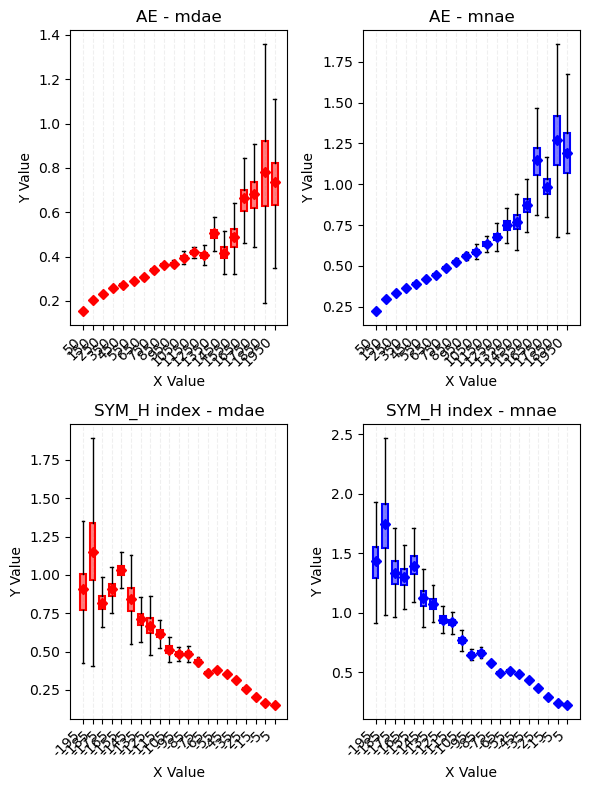

In [18]:
p = inspect.plot_boxplot_metvx(met_box,figsize=(6,8), colors=['red', 'blue'],alphas=[0.5], 
                               separate_by='both')

The Residual Box Plot vs X notebook has some additonal notes on plotting and chaning the box propoerties when plotting.

[Notebook](Residual_boxvx.ipynb)